# NYC Taxi Trip Duration — Full ML Pipeline
**Problem:** Predict how long a taxi trip will take (in seconds) given pickup location, time, and passenger info.

**Type:** Regression  
**Target:** `trip_duration` (seconds)  
**Model:** LightGBM

---
## Table of Contents
1. Imports & Setup
2. Load Data
3. Exploratory Data Analysis (EDA)
4. Outlier Removal
5. Feature Engineering
6. Preprocessing
7. Train/Test Split
8. Model Training
9. Evaluation
10. Feature Importance
11. Prediction on New Data

---
## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

# Consistent plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

SEED = 42
np.random.seed(SEED)
print('All libraries loaded.')

All libraries loaded.


---
## 2. Load Data

In [2]:
df = pd.read_csv('/Users/apple/ML PROJECT /notebook/data/raw_data.csv')

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Shape: (1458644, 11)
Rows: 1,458,644 | Columns: 11


,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [3]:
print('Column dtypes:')
print(df.dtypes)
print()
print('Missing values:')
print(df.isnull().sum())

Column dtypes:
id                        str
vendor_id               int64
pickup_datetime           str
dropoff_datetime          str
passenger_count         int64
pickup_longitude      float64
pickup_latitude       float64
dropoff_longitude     float64
dropoff_latitude      float64
store_and_fwd_flag        str
trip_duration           int64
dtype: object

Missing values:
id                    0
vendor_id             0
pickup_datetime       0
dropoff_datetime      0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
dtype: int64


In [4]:
print('Basic statistics:')
df.describe()

Basic statistics:


,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06,1.458644e+06
mean,1.534950e+00,1.664530e+00,-7.397349e+01,4.075092e+01,-7.397342e+01,4.075180e+01,9.594923e+02
std,4.987772e-01,1.314242e+00,7.090186e-02,3.288119e-02,7.064327e-02,3.589056e-02,5.237432e+03
min,1.000000e+00,0.000000e+00,-1.219333e+02,3.435970e+01,-1.219333e+02,3.218114e+01,1.000000e+00
25%,1.000000e+00,1.000000e+00,-7.399187e+01,4.073735e+01,-7.399133e+01,4.073588e+01,3.970000e+02
50%,2.000000e+00,1.000000e+00,-7.398174e+01,4.075410e+01,-7.397975e+01,4.075452e+01,6.620000e+02
75%,2.000000e+00,2.000000e+00,-7.396733e+01,4.076836e+01,-7.396301e+01,4.076981e+01,1.075000e+03
max,2.000000e+00,9.000000e+00,-6.133553e+01,5.188108e+01,-6.133553e+01,4.392103e+01,3.526282e+06


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

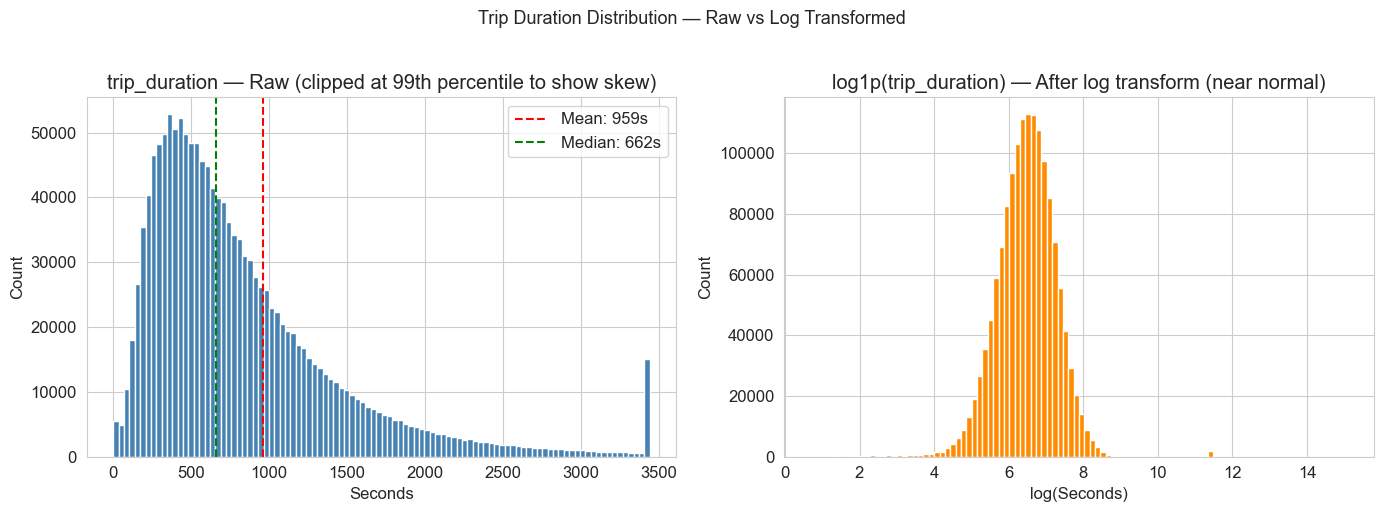

Clipped at: 3440 sec (99th percentile)
Mean:   959 sec
Median: 662 sec
Note: Mean > Median confirms right skew


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left plot: clip at 99th percentile so skew is visible ---
clip_val = np.percentile(df['trip_duration'], 99)  # 3440 seconds
plot_data = df['trip_duration'].clip(upper=clip_val)

axes[0].hist(plot_data, bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('trip_duration — Raw (clipped at 99th percentile to show skew)')
axes[0].set_xlabel('Seconds')
axes[0].set_ylabel('Count')
axes[0].axvline(df['trip_duration'].mean(), color='red', linestyle='--', label=f"Mean: {df['trip_duration'].mean():.0f}s")
axes[0].axvline(df['trip_duration'].median(), color='green', linestyle='--', label=f"Median: {df['trip_duration'].median():.0f}s")
axes[0].legend()

# --- Right plot: log transform ---
axes[1].hist(np.log1p(df['trip_duration']), bins=100, color='darkorange', edgecolor='white')
axes[1].set_title('log1p(trip_duration) — After log transform (near normal)')
axes[1].set_xlabel('log(Seconds)')
axes[1].set_ylabel('Count')

plt.suptitle('Trip Duration Distribution — Raw vs Log Transformed', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Clipped at: {clip_val:.0f} sec (99th percentile)")
print(f"Mean:   {df['trip_duration'].mean():.0f} sec")
print(f"Median: {df['trip_duration'].median():.0f} sec")
print(f"Note: Mean > Median confirms right skew")

### 3.2 Categorical Features

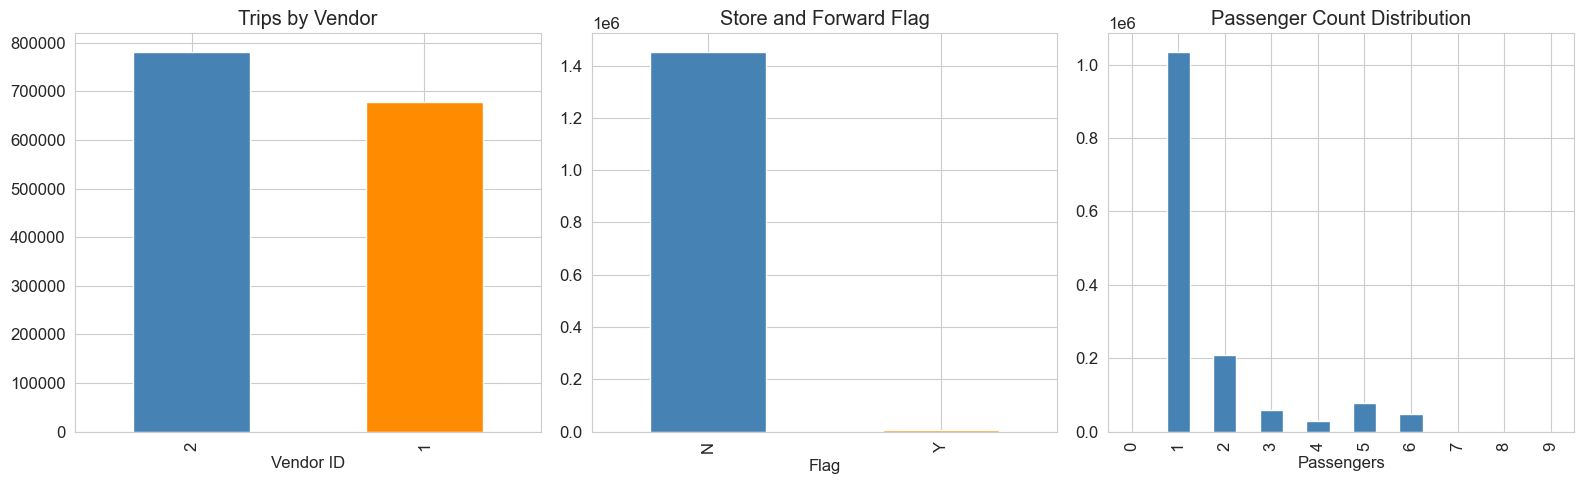

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# vendor_id
df['vendor_id'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','darkorange'])
axes[0].set_title('Trips by Vendor')
axes[0].set_xlabel('Vendor ID')

# store_and_fwd_flag
df['store_and_fwd_flag'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue','darkorange'])
axes[1].set_title('Store and Forward Flag')
axes[1].set_xlabel('Flag')

# passenger_count
df['passenger_count'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('Passenger Count Distribution')
axes[2].set_xlabel('Passengers')

plt.tight_layout()
plt.show()

### 3.3 Geographic Distribution of Pickups

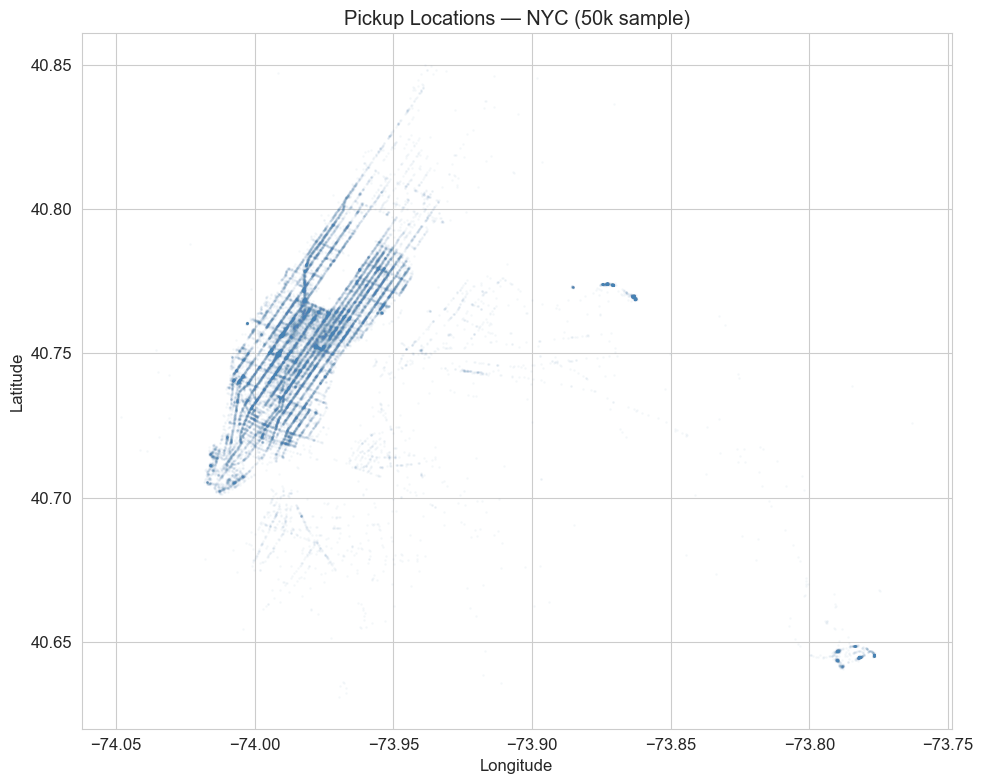

In [7]:
# Filter to NYC bounding box to remove GPS noise
nyc_mask = (
    (df['pickup_longitude'].between(-74.05, -73.75)) &
    (df['pickup_latitude'].between(40.63, 40.85))
)
sample = df[nyc_mask].sample(50000, random_state=SEED)

plt.figure(figsize=(10, 8))
plt.scatter(
    sample['pickup_longitude'],
    sample['pickup_latitude'],
    alpha=0.03, s=1, c='steelblue'
)
plt.title('Pickup Locations — NYC (50k sample)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

### 3.4 Time Patterns

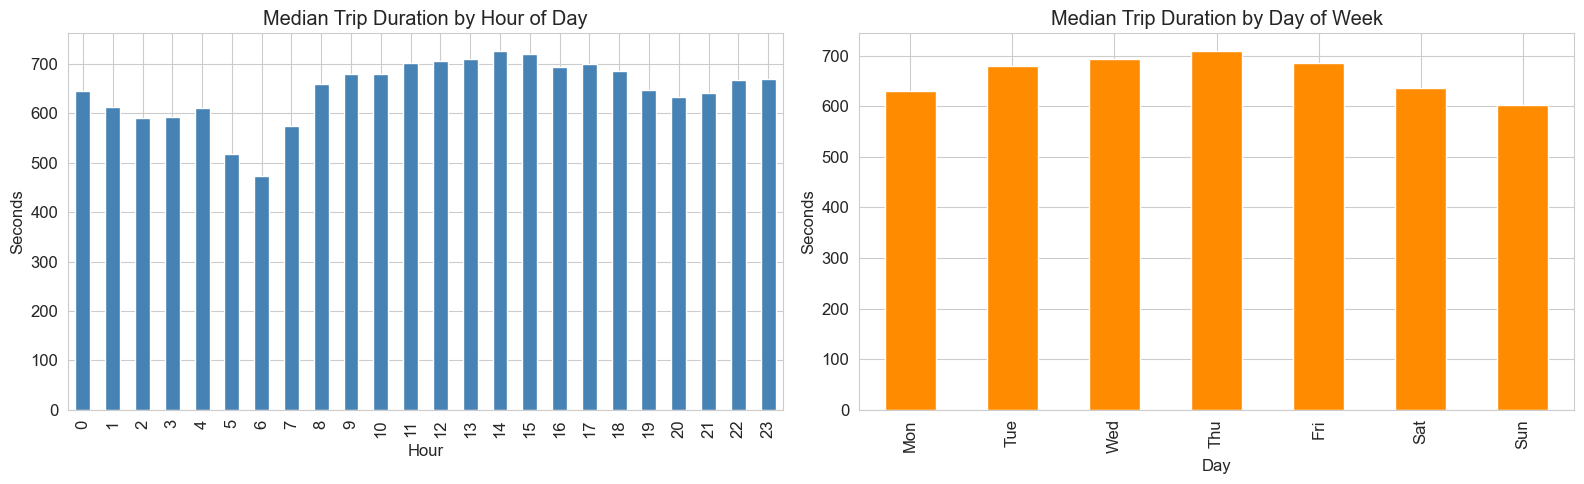

In [8]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

temp = df.copy()
temp['hour'] = temp['pickup_datetime'].dt.hour
temp['day_of_week'] = temp['pickup_datetime'].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average duration by hour
hourly = temp.groupby('hour')['trip_duration'].median()
hourly.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Median Trip Duration by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Seconds')

# Average duration by day
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
daily = temp.groupby('day_of_week')['trip_duration'].median()
daily.index = days
daily.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Median Trip Duration by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Seconds')

plt.tight_layout()
plt.show()

### 3.5 Correlation Heatmap

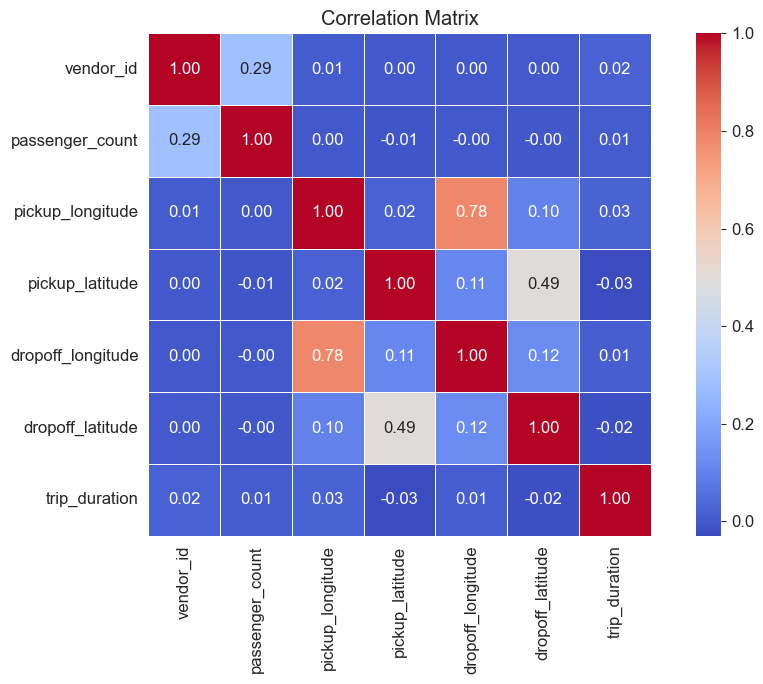

In [9]:
numeric_cols = ['vendor_id','passenger_count','pickup_longitude','pickup_latitude',
                'dropoff_longitude','dropoff_latitude','trip_duration']

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numeric_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm',
    square=True, linewidths=0.5
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

---
## 4. Outlier Removal

**Rules:**
- `trip_duration < 60s` → not a real trip
- `trip_duration > 7200s` → 2+ hour trips are extreme outliers
- `passenger_count == 0` → invalid
- Coordinates outside NYC bounding box → GPS error

In [10]:
print(f'Before outlier removal: {len(df):,} rows')

df = df[
    (df['trip_duration'] >= 60) &
    (df['trip_duration'] <= 7200) &
    (df['passenger_count'] > 0) &
    (df['passenger_count'] <= 6) &
    (df['pickup_longitude'].between(-74.05, -73.75)) &
    (df['pickup_latitude'].between(40.63, 40.85)) &
    (df['dropoff_longitude'].between(-74.05, -73.75)) &
    (df['dropoff_latitude'].between(40.63, 40.85))
].copy()

print(f'After outlier removal:  {len(df):,} rows')
print(f'Rows removed: {1458644 - len(df):,}')
df.reset_index(drop=True, inplace=True)

Before outlier removal: 1,458,644 rows
After outlier removal:  1,429,604 rows
Rows removed: 29,040


---
## 5. Feature Engineering

### 5.1 Drop Leaky and Useless Columns

> `dropoff_datetime` is **data leakage** — you don't know the dropoff time before the trip ends.  
> `id` is just an identifier.

In [11]:
df.drop(columns=['id', 'dropoff_datetime'], inplace=True)
print('Dropped: id, dropoff_datetime')
print('Remaining columns:', df.columns.tolist())

Dropped: id, dropoff_datetime
Remaining columns: ['vendor_id', 'pickup_datetime', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'trip_duration']


### 5.2 Datetime Features

In [12]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

df['hour']        = df['pickup_datetime'].dt.hour
df['day_of_week'] = df['pickup_datetime'].dt.dayofweek   # 0=Mon, 6=Sun
df['month']       = df['pickup_datetime'].dt.month
df['day_of_month']= df['pickup_datetime'].dt.day
df['week_of_year']= df['pickup_datetime'].dt.isocalendar().week.astype(int)
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)

# Rush hour: 7-9am and 4-7pm on weekdays
df['is_rush_hour'] = (
    (df['is_weekend'] == 0) &
    (df['hour'].isin([7, 8, 9, 16, 17, 18, 19]))
).astype(int)

# Night time: 11pm - 5am
df['is_night'] = (df['hour'].isin([23, 0, 1, 2, 3, 4, 5])).astype(int)

df.drop(columns=['pickup_datetime'], inplace=True)

print('Datetime features created:')
print(['hour','day_of_week','month','day_of_month','week_of_year',
       'is_weekend','is_rush_hour','is_night'])

Datetime features created:
['hour', 'day_of_week', 'month', 'day_of_month', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night']


### 5.3 Haversine Distance

Straight-line distance between pickup and dropoff in km. Will be the **strongest single predictor**.

In [13]:
def haversine_vectorized(lat1, lon1, lat2, lon2):
    """Vectorized haversine — handles full column at once, much faster than apply."""
    R = 6371.0  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

df['distance_km'] = haversine_vectorized(
    df['pickup_latitude'],  df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

print(f"Distance range: {df['distance_km'].min():.3f} — {df['distance_km'].max():.2f} km")
print(f"Mean distance: {df['distance_km'].mean():.2f} km")

Distance range: 0.000 — 27.19 km
Mean distance: 3.31 km


### 5.4 Direction (Bearing)

In [14]:
df['direction'] = np.degrees(
    np.arctan2(
        df['dropoff_latitude']  - df['pickup_latitude'],
        df['dropoff_longitude'] - df['pickup_longitude']
    )
)

print('Direction feature (bearing in degrees) created.')

Direction feature (bearing in degrees) created.


### 5.5 Coordinate Differences

In [15]:
df['delta_lat'] = df['dropoff_latitude']  - df['pickup_latitude']
df['delta_lon'] = df['dropoff_longitude'] - df['pickup_longitude']

# Manhattan distance in coordinate space (proxy for grid distance)
df['manhattan_dist'] = np.abs(df['delta_lat']) + np.abs(df['delta_lon'])

print('Coordinate diff features created: delta_lat, delta_lon, manhattan_dist')

Coordinate diff features created: delta_lat, delta_lon, manhattan_dist


### 5.6 Distance = 0 Flag

In [16]:
df['zero_distance'] = (df['distance_km'] < 0.05).astype(int)
print(f"Trips with near-zero distance: {df['zero_distance'].sum():,}")

Trips with near-zero distance: 5,889


### 5.7 Encode Categorical

In [17]:
df['store_and_fwd_flag'] = (df['store_and_fwd_flag'] == 'Y').astype(int)
print('store_and_fwd_flag encoded: Y=1, N=0')
print(f'Value counts: {df["store_and_fwd_flag"].value_counts().to_dict()}')

store_and_fwd_flag encoded: Y=1, N=0
Value counts: {0: 1421848, 1: 7756}


### 5.8 Final Feature Summary

In [18]:
print('Final dataframe shape:', df.shape)
print()
print('All columns:')
for col in df.columns:
    print(f'  {col:<25} {df[col].dtype}')

Final dataframe shape: (1429604, 22)

All columns:
  vendor_id                 int64
  passenger_count           int64
  pickup_longitude          float64
  pickup_latitude           float64
  dropoff_longitude         float64
  dropoff_latitude          float64
  store_and_fwd_flag        int64
  trip_duration             int64
  hour                      int32
  day_of_week               int32
  month                     int32
  day_of_month              int32
  week_of_year              int64
  is_weekend                int64
  is_rush_hour              int64
  is_night                  int64
  distance_km               float64
  direction                 float64
  delta_lat                 float64
  delta_lon                 float64
  manhattan_dist            float64
  zero_distance             int64


---
## 6. Preprocessing

### 6.1 Log-Transform the Target

Trip duration is right-skewed. Log transform makes it approximately normal,
which helps all regression models (especially gradient boosting on error terms).

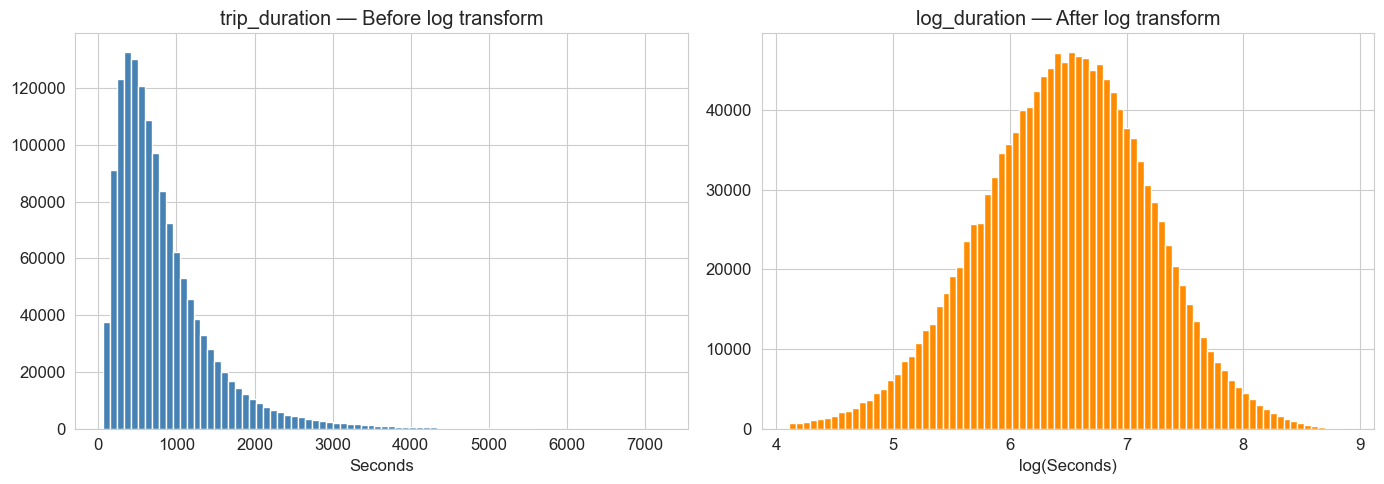

In [19]:
df['log_duration'] = np.log1p(df['trip_duration'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['trip_duration'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('trip_duration — Before log transform')
axes[0].set_xlabel('Seconds')

axes[1].hist(df['log_duration'], bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('log_duration — After log transform')
axes[1].set_xlabel('log(Seconds)')

plt.tight_layout()
plt.show()

### 6.2 Define Features and Target

In [20]:
TARGET = 'log_duration'

# Drop raw target (keep log version) and any ID-like columns
DROP_COLS = ['trip_duration', 'log_duration']

FEATURES = [col for col in df.columns if col not in DROP_COLS]

print(f'Number of features: {len(FEATURES)}')
print('Features:', FEATURES)

Number of features: 21
Features: ['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag', 'hour', 'day_of_week', 'month', 'day_of_month', 'week_of_year', 'is_weekend', 'is_rush_hour', 'is_night', 'distance_km', 'direction', 'delta_lat', 'delta_lon', 'manhattan_dist', 'zero_distance']


---
## 7. Train / Test Split

In [21]:
X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print(f'Train size: {X_train.shape[0]:,} rows')
print(f'Test size:  {X_test.shape[0]:,} rows')
print(f'Features:   {X_train.shape[1]}')

Train size: 1,143,683 rows
Test size:  285,921 rows
Features:   21


---
## 8. Model Training — LightGBM

Why LightGBM:
- Best accuracy/speed tradeoff for tabular regression at this scale
- Handles non-linear relationships naturally
- No need to scale features
- Built-in early stopping to avoid overfitting

In [22]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_test,  label=y_test, reference=lgb_train)

params = {
    'objective'       : 'regression',      # MSE loss
    'metric'          : 'rmse',
    'boosting_type'   : 'gbdt',
    'num_leaves'      : 63,                # Controls tree complexity. Higher = more complex = more likely to overfit
    'learning_rate'   : 0.05,             # Smaller = more trees needed but usually better
    'feature_fraction': 0.8,              # Use 80% of features per tree — adds randomness, reduces overfitting
    'bagging_fraction': 0.8,              # Use 80% of rows per tree
    'bagging_freq'    : 5,
    'min_child_samples': 20,
    'reg_alpha'       : 0.1,              # L1 regularization
    'reg_lambda'      : 0.1,              # L2 regularization
    'random_state'    : SEED,
    'n_jobs'          : -1,
    'verbose'         : -1
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)
]

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_val],
    callbacks=callbacks
)

print(f'\nBest iteration: {model.best_iteration}')

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.337114
[200]	valid_0's rmse: 0.32148
[300]	valid_0's rmse: 0.316427
[400]	valid_0's rmse: 0.313861
[500]	valid_0's rmse: 0.311804
[600]	valid_0's rmse: 0.310376
[700]	valid_0's rmse: 0.309133
[800]	valid_0's rmse: 0.308106
[900]	valid_0's rmse: 0.307078
[1000]	valid_0's rmse: 0.306201
[1100]	valid_0's rmse: 0.305467
[1200]	valid_0's rmse: 0.304776
[1300]	valid_0's rmse: 0.304206
[1400]	valid_0's rmse: 0.303858
[1500]	valid_0's rmse: 0.303383
[1600]	valid_0's rmse: 0.302896
[1700]	valid_0's rmse: 0.302502
[1800]	valid_0's rmse: 0.3022
[1900]	valid_0's rmse: 0.302002
[2000]	valid_0's rmse: 0.301697
Did not meet early stopping. Best iteration is:
[2000]	valid_0's rmse: 0.301697

Best iteration: 2000


---
## 9. Evaluation

In [23]:
# Predict in log space, then convert back to seconds
y_pred_log = model.predict(X_test, num_iteration=model.best_iteration)
y_pred     = np.expm1(y_pred_log)    # inverse of log1p
y_true     = np.expm1(y_test)

# Metrics
rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
mae   = mean_absolute_error(y_true, y_pred)
r2    = r2_score(y_true, y_pred)

# RMSLE — standard metric for this dataset (Kaggle)
rmsle = np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(np.clip(y_pred, 0, None))))

print('=' * 40)
print('         MODEL PERFORMANCE')
print('=' * 40)
print(f'  RMSE  : {rmse:.2f}  seconds')
print(f'  MAE   : {mae:.2f}  seconds  ({mae/60:.1f} minutes)')
print(f'  RMSLE : {rmsle:.4f}  (lower is better; Kaggle metric)')
print(f'  R²    : {r2:.4f}  (1.0 = perfect)')
print('=' * 40)
print()
print(f'On average, predictions are off by ±{mae/60:.1f} minutes.')

         MODEL PERFORMANCE
  RMSE  : 268.10  seconds
  MAE   : 160.86  seconds  (2.7 minutes)
  RMSLE : 0.3017  (lower is better; Kaggle metric)
  R²    : 0.8244  (1.0 = perfect)

On average, predictions are off by ±2.7 minutes.


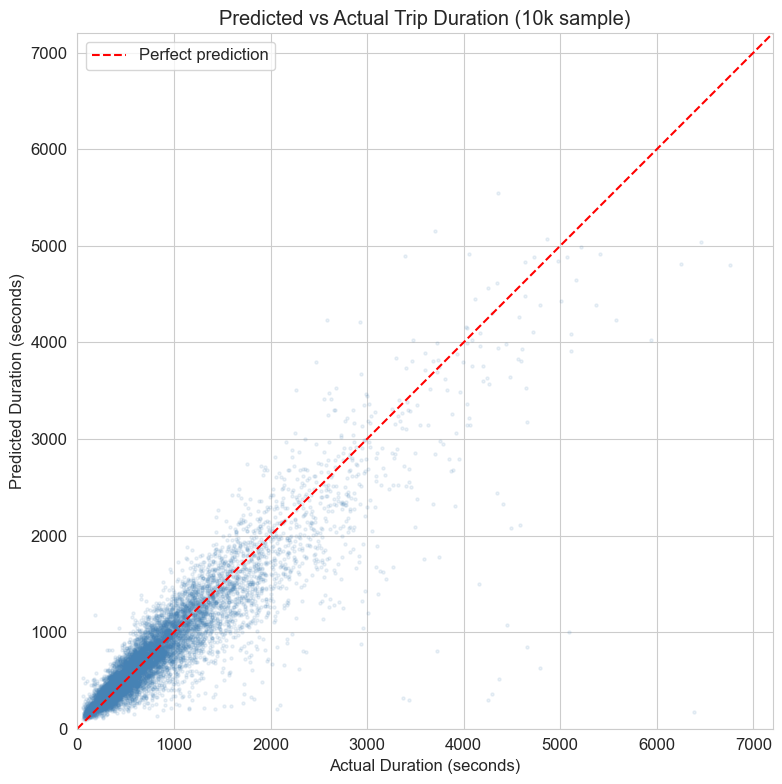

In [24]:
# Predicted vs Actual scatter
sample_idx = np.random.choice(len(y_true), size=10000, replace=False)
y_true_s = np.array(y_true)[sample_idx]
y_pred_s = y_pred[sample_idx]

plt.figure(figsize=(8, 8))
plt.scatter(y_true_s, y_pred_s, alpha=0.1, s=5, c='steelblue')
plt.plot([0, 7200], [0, 7200], 'r--', lw=1.5, label='Perfect prediction')
plt.xlabel('Actual Duration (seconds)')
plt.ylabel('Predicted Duration (seconds)')
plt.title('Predicted vs Actual Trip Duration (10k sample)')
plt.legend()
plt.xlim(0, 7200)
plt.ylim(0, 7200)
plt.tight_layout()
plt.show()

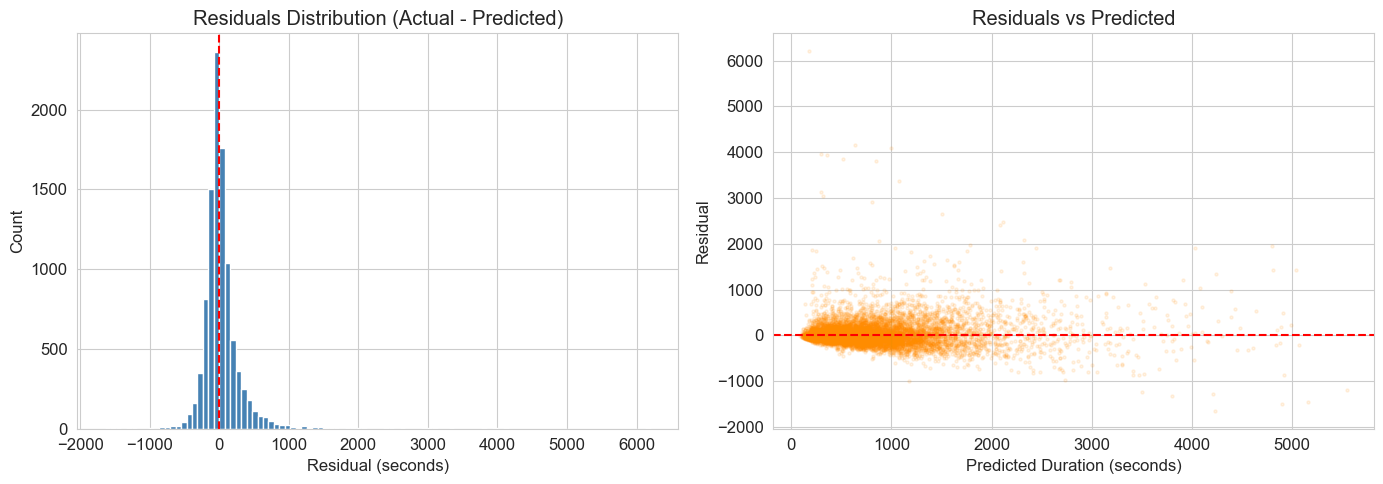

In [25]:
# Residual distribution
residuals = y_true_s - y_pred_s

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(residuals, bins=100, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Distribution (Actual - Predicted)')
axes[0].set_xlabel('Residual (seconds)')
axes[0].set_ylabel('Count')

# Residuals vs Predicted
axes[1].scatter(y_pred_s, residuals, alpha=0.1, s=5, c='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted')
axes[1].set_xlabel('Predicted Duration (seconds)')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.show()

---
## 10. Feature Importance

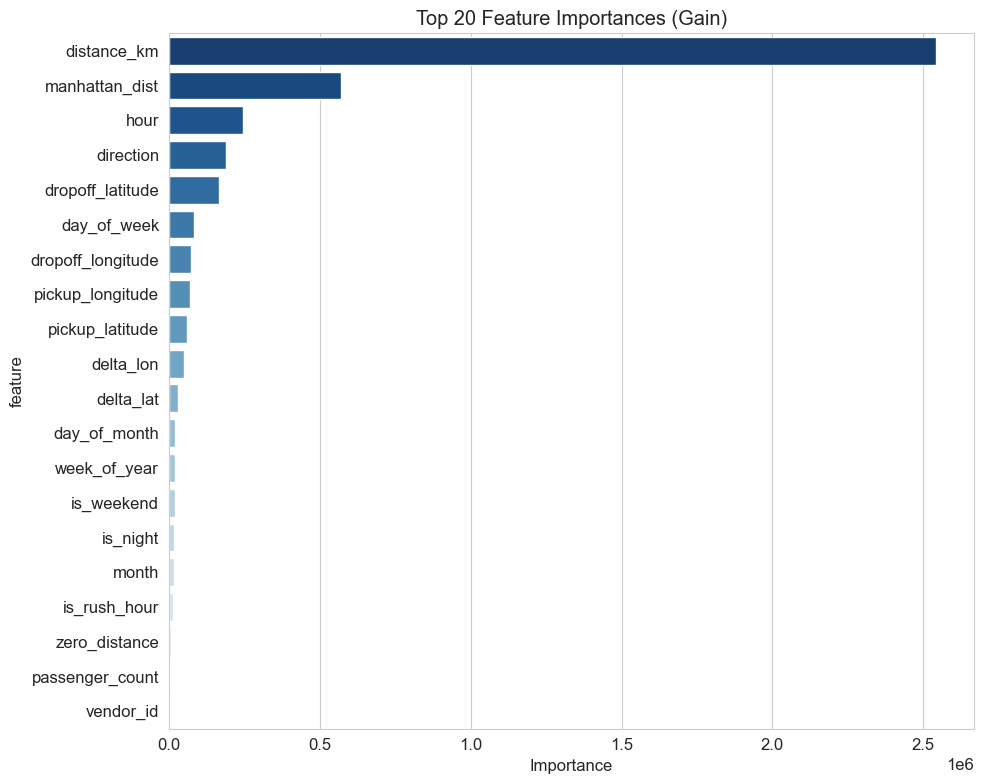

Top 10 features:
          feature   importance
      distance_km 2.541136e+06
   manhattan_dist 5.698898e+05
             hour 2.446029e+05
        direction 1.888744e+05
 dropoff_latitude 1.647800e+05
      day_of_week 8.340347e+04
dropoff_longitude 7.281746e+04
 pickup_longitude 7.025931e+04
  pickup_latitude 6.041416e+04
        delta_lon 5.142757e+04


In [26]:
importance_df = pd.DataFrame({
    'feature'   : model.feature_name(),
    'importance': model.feature_importance(importance_type='gain')  # 'gain' is more reliable than 'split'
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df.head(20),
    x='importance', y='feature',
    palette='Blues_r'
)
plt.title('Top 20 Feature Importances (Gain)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(importance_df.head(10).to_string(index=False))

---
## 11. Predict on a New Trip

Example: How long will a trip from Midtown Manhattan to JFK Airport take at 8am on a Tuesday?

In [27]:
def predict_trip_duration(
    pickup_lat, pickup_lon,
    dropoff_lat, dropoff_lon,
    hour, day_of_week, month=6,
    passenger_count=1, vendor_id=2,
    store_and_fwd_flag=0
):
    """Predict trip duration in seconds given trip details."""

    dist_km = haversine_vectorized(
        np.array([pickup_lat]),  np.array([pickup_lon]),
        np.array([dropoff_lat]), np.array([dropoff_lon])
    )[0]

    inp = {
        'vendor_id'          : vendor_id,
        'passenger_count'    : passenger_count,
        'pickup_longitude'   : pickup_lon,
        'pickup_latitude'    : pickup_lat,
        'dropoff_longitude'  : dropoff_lon,
        'dropoff_latitude'   : dropoff_lat,
        'store_and_fwd_flag' : store_and_fwd_flag,
        'hour'               : hour,
        'day_of_week'        : day_of_week,
        'month'              : month,
        'day_of_month'       : 15,
        'week_of_year'       : 24,
        'is_weekend'         : int(day_of_week >= 5),
        'is_rush_hour'       : int(day_of_week < 5 and hour in [7,8,9,16,17,18,19]),
        'is_night'           : int(hour in [23,0,1,2,3,4,5]),
        'distance_km'        : dist_km,
        'direction'          : np.degrees(np.arctan2(dropoff_lat - pickup_lat, dropoff_lon - pickup_lon)),
        'delta_lat'          : dropoff_lat - pickup_lat,
        'delta_lon'          : dropoff_lon - pickup_lon,
        'manhattan_dist'     : abs(dropoff_lat - pickup_lat) + abs(dropoff_lon - pickup_lon),
        'zero_distance'      : int(dist_km < 0.05)
    }

    row = pd.DataFrame([inp])[FEATURES]
    pred_log = model.predict(row, num_iteration=model.best_iteration)[0]
    pred_sec = np.expm1(pred_log)

    return pred_sec


# ---- Example: Midtown to JFK, Tuesday 8am ----
duration_sec = predict_trip_duration(
    pickup_lat=40.7549, pickup_lon=-73.9840,   # Midtown Manhattan
    dropoff_lat=40.6413, dropoff_lon=-73.7781, # JFK Airport
    hour=8, day_of_week=1, month=6             # Tuesday 8am
)

print(f'Predicted trip duration: {duration_sec:.0f} seconds')
print(f'                       = {duration_sec/60:.1f} minutes')

Predicted trip duration: 2789 seconds
                       = 46.5 minutes


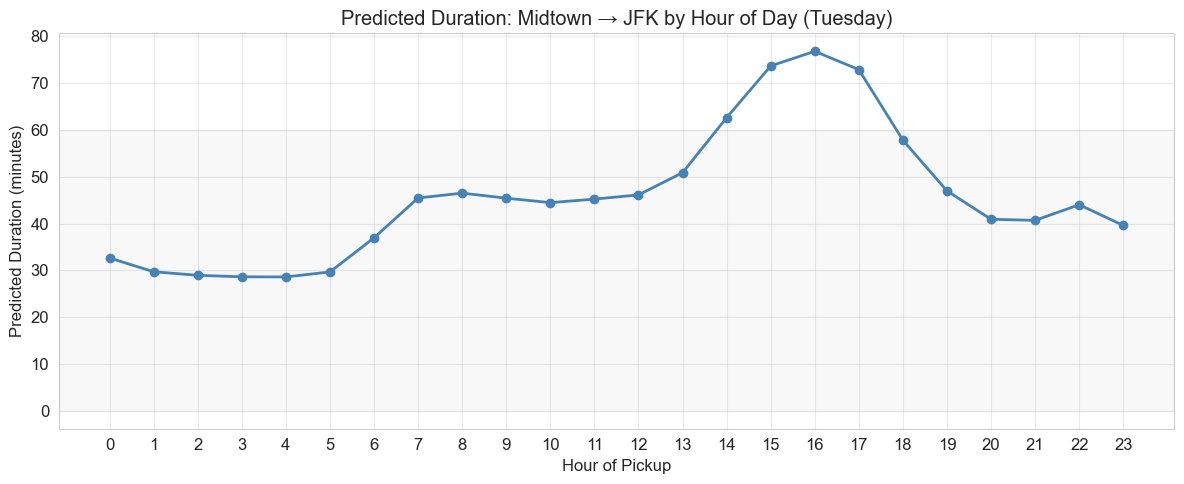

In [28]:
# Same trip at different hours — see how predictions vary
hours = list(range(0, 24))
predictions = [
    predict_trip_duration(
        pickup_lat=40.7549, pickup_lon=-73.9840,
        dropoff_lat=40.6413, dropoff_lon=-73.7781,
        hour=h, day_of_week=1, month=6
    ) / 60  # convert to minutes
    for h in hours
]

plt.figure(figsize=(12, 5))
plt.plot(hours, predictions, marker='o', color='steelblue', linewidth=2)
plt.axhspan(0, 60, alpha=0.05, color='gray')
plt.title('Predicted Duration: Midtown → JFK by Hour of Day (Tuesday)')
plt.xlabel('Hour of Pickup')
plt.ylabel('Predicted Duration (minutes)')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
## Summary

| Step | What was done |
|---|---|
| **Data** | 1.46M rows, 11 columns, no nulls |
| **Outlier Removal** | Removed trips < 60s, > 7200s, invalid coords/passengers |
| **Leaked Columns Dropped** | `dropoff_datetime`, `id` |
| **Features Created** | hour, day_of_week, month, is_weekend, is_rush_hour, is_night, distance_km, direction, delta_lat/lon, manhattan_dist |
| **Target Transform** | log1p(trip_duration) — undone with expm1 after prediction |
| **Model** | LightGBM with early stopping (2000 round max) |
| **Metric** | RMSLE (Kaggle standard), MAE, R² |

**Key insight:** `distance_km` and `hour` dominate predictions. The model understands that the same physical distance takes much longer at rush hour.